SECTION 0 — SETUP

In [1]:
# Section 0 — Setup
# Imports, path configuration, and logging initialisation.
# This cell must run before any other cell in the notebook.
 
import sys
import warnings
from pathlib import Path
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
 
# Ensure src/ is importable from the notebooks/ directory
sys.path.insert(0, str(Path.cwd().parent))
 
from src.config import (
    NFHS5_CLEANED_PATH, TARGET_COLS,
    FIGURES_DIR, TABLES_DIR,
)
from src.logger import get_console_logger
from src.validation import check_prevalence, ValidationError, PREVALENCE_THRESHOLDS
from src.utils import format_number
 
warnings.filterwarnings('ignore')
log = get_console_logger('01_data_loading')
 
# Plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['savefig.dpi']    = 150
plt.rcParams['savefig.bbox']   = 'tight'
 
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
 
print('Setup complete')
print(f'NFHS5_CLEANED_PATH: {NFHS5_CLEANED_PATH}')
print(f'FIGURES_DIR:        {FIGURES_DIR}')


Setup complete
NFHS5_CLEANED_PATH: /workspaces/malnutrisense/data/processed/nfhs5_cleaned.csv
FIGURES_DIR:        /workspaces/malnutrisense/reports/figures


In [2]:
# Confirm the cleaned dataset exists before proceeding.
# If this cell raises FileNotFoundError, run scripts/run_pipeline.py first.
if not NFHS5_CLEANED_PATH.exists():
    raise FileNotFoundError(
        f'Cleaned dataset not found: {NFHS5_CLEANED_PATH}\n'
        'Run: python3 scripts/run_pipeline.py'
    )
print(f'Dataset found: {NFHS5_CLEANED_PATH.name}')
print(f'File size: {NFHS5_CLEANED_PATH.stat().st_size / 1e6:.1f} MB')
 


Dataset found: nfhs5_cleaned.csv
File size: 17.1 MB


SECTION 1 — LOAD DATA

In [3]:
# Section 1 — Load Data
# Load the processed dataset. Use usecols sparingly — load all columns for EDA.
 
df = pd.read_csv(NFHS5_CLEANED_PATH)
 
# ── Fallback: uncomment below if pipeline CSV not available ──
# FALLBACK = Path('data/raw/external/nfhs_github_backup/...')
# df = pd.read_csv(FALLBACK)  # district-level only — for EDA structure test
 
log.info(f'Loaded: {format_number(len(df))} rows x {df.shape[1]} columns')
print(f'Shape:   {df.shape}')
print(f'Columns: {list(df.columns)}')
 


2026-05-02 04:46:08  INFO      01_data_loading: Loaded: 228,356 rows x 17 columns
Shape:   (228356, 17)
Columns: ['v024', 'v025', 'v106', 'v130', 'b4', 'm4', 'm19', 'h11', 'hw1', 'hw2', 'hw3', 'HAZ', 'WAZ', 'WHZ', 'stunted', 'underweight', 'wasted']


In [4]:
# Display data types and a sample of the loaded DataFrame.
display(df.dtypes.rename('dtype').to_frame())
df.head(3)
 


,dtype
v024,float64
v025,float64
v106,float64
v130,float64
b4,float64
m4,float64
m19,float64
h11,float64
hw1,float64
hw2,float64


,v024,v025,v106,v130,b4,m4,m19,h11,hw1,hw2,hw3,HAZ,WAZ,WHZ,stunted,underweight,wasted
0,1.0,2.0,2.0,2.0,1.0,24.0,3000.0,0.0,51.0,131.0,1283.0,5.26,-2.07,NaN,0.0,1.0,NaN
1,1.0,2.0,1.0,2.0,2.0,95.0,2400.0,0.0,12.0,111.0,900.0,5.65,1.50,-1.39,0.0,0.0,0.0
2,1.0,2.0,2.0,2.0,2.0,95.0,2870.0,0.0,25.0,145.0,1027.0,4.61,1.53,-1.16,0.0,0.0,0.0


SECTION 2 — MISSING VALUES

In [5]:
# Section 2 — Missing Value Audit
# After full preprocessing, feature columns should have 0 missing values.
# Z-score columns (HAZ/WAZ/WHZ) and SC/ST column may have NaN (expected).
 
missing = df.isnull().mean().sort_values(ascending=False)
missing_any = missing[missing > 0]
 
if len(missing_any) == 0:
    print('All columns: 0 missing values')
else:
    print(f'{len(missing_any)} columns with missing values:')
    for col, pct in missing_any.items():
        count = int(df[col].isnull().sum())
        print(f'  {col:<25} {count:>8,}  ({pct:.1%})')
 


6 columns with missing values:
  wasted                      26,676  (11.7%)
  WHZ                         26,676  (11.7%)
  stunted                     22,338  (9.8%)
  HAZ                         22,338  (9.8%)
  underweight                 17,841  (7.8%)
  WAZ                         17,841  (7.8%)


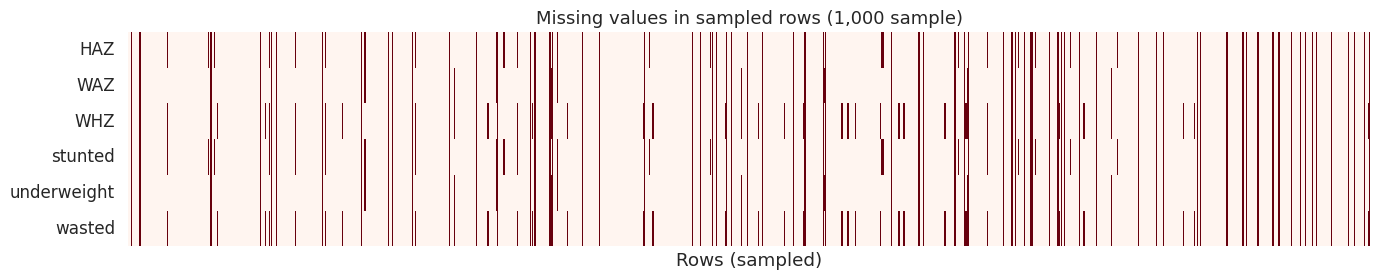

Saved: /workspaces/malnutrisense/reports/figures/missing_values_heatmap.png


In [6]:
# Visualise missing values as a heatmap.
# A completely empty heatmap (all white) = no missing values in feature columns.
fig, ax = plt.subplots(figsize=(14, 3))
 
# Show only columns with any missing values
cols_with_missing = [c for c in df.columns if df[c].isnull().any()]
if cols_with_missing:
    sns.heatmap(
        df[cols_with_missing].isnull().sample(min(1000, len(df)), random_state=42).T,
        cbar=False, ax=ax, cmap='Reds', xticklabels=False
    )
    ax.set_title('Missing values in sampled rows (1,000 sample)', fontsize=13)
    ax.set_xlabel('Rows (sampled)')
else:
    ax.text(0.5, 0.5, 'No missing values in any column',
            ha='center', va='center', transform=ax.transAxes, fontsize=14)
    ax.set_title('Missing value heatmap', fontsize=13)
 
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'missing_values_heatmap.png')
plt.show()
print(f'Saved: {FIGURES_DIR}/missing_values_heatmap.png')
 


SECTION 3 — Z-SCORE DISTRIBUTIONS

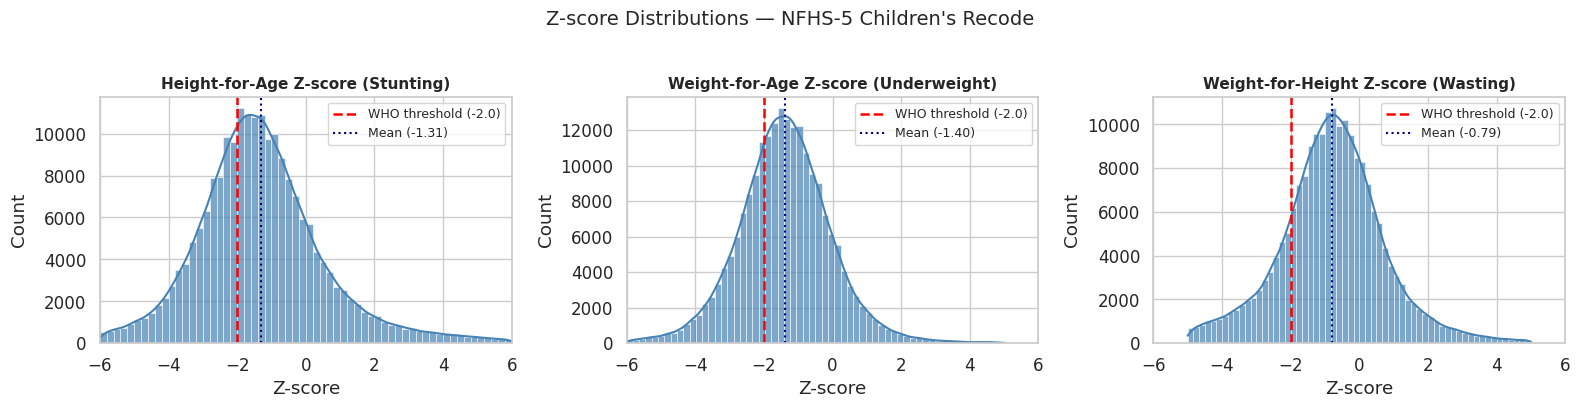

Saved: /workspaces/malnutrisense/reports/figures/zscore_distributions.png


In [7]:
# Section 3 — Z-score Distributions
# Three panels: HAZ (stunting), WAZ (underweight), WHZ (wasting).
# Each distribution should be bell-shaped, centred around -1 to -2.
# The WHO threshold line at -2.0 marks the malnourished boundary.
 
z_cols   = ['HAZ', 'WAZ', 'WHZ']
z_labels = {
    'HAZ': 'Height-for-Age Z-score (Stunting)',
    'WAZ': 'Weight-for-Age Z-score (Underweight)',
    'WHZ': 'Weight-for-Height Z-score (Wasting)',
}
 
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
 
for ax, col in zip(axes, z_cols):
    data = df[col].dropna()
    sns.histplot(data, bins=60, kde=True, ax=ax, color='steelblue', alpha=0.7)
    ax.axvline(x=-2.0, color='red', linewidth=1.8, linestyle='--',
               label='WHO threshold (-2.0)')
    ax.axvline(x=data.mean(), color='navy', linewidth=1.5, linestyle=':',
               label=f'Mean ({data.mean():.2f})')
    ax.set_title(z_labels[col], fontsize=11, fontweight='bold')
    ax.set_xlabel('Z-score')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
    ax.set_xlim(-6, 6)
 
plt.suptitle('Z-score Distributions — NFHS-5 Children\'s Recode',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'zscore_distributions.png')
plt.show()
print(f'Saved: {FIGURES_DIR}/zscore_distributions.png')
 


In [8]:
# Descriptive statistics for Z-score columns.
# Mean, std, min, max — all should be within [-6, +6] after cleaning.
z_stats = df[z_cols].describe().round(3)
display(z_stats)
 
# Confirm no values outside physiological bounds
for col in z_cols:
    valid = df[col].dropna()
    n_out = (~valid.between(-6, 6)).sum()
    print(f'{col}: {len(valid):,} valid values, {n_out} outside [-6, +6]')
 


,HAZ,WAZ,WHZ
count,206018.000,210515.000,201680.000
mean,-1.312,-1.395,-0.788
std,1.837,1.346,1.532
min,-6.000,-6.000,-5.000
25%,-2.450,-2.220,-1.680
50%,-1.450,-1.410,-0.780
75%,-0.360,-0.580,0.100
max,6.000,5.000,5.000


HAZ: 206,018 valid values, 0 outside [-6, +6]
WAZ: 210,515 valid values, 0 outside [-6, +6]
WHZ: 201,680 valid values, 0 outside [-6, +6]


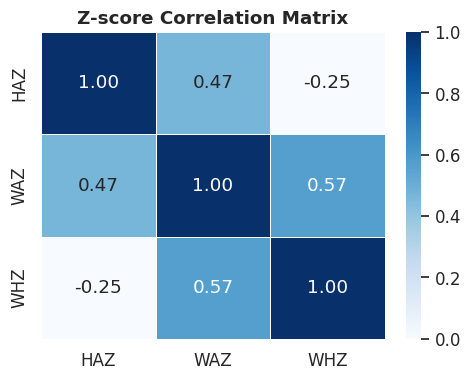

Saved: /workspaces/malnutrisense/reports/figures/zscore_correlation.png


In [9]:
# Z-score correlation — stunting, underweight, and wasting co-occur.
# Strong positive correlation is expected (shared biological determinants).
fig, ax = plt.subplots(figsize=(5, 4))
corr = df[z_cols].corr().round(2)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=z_cols, yticklabels=z_cols, ax=ax,
            vmin=0, vmax=1, linewidths=0.5)
ax.set_title('Z-score Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'zscore_correlation.png')
plt.show()
print(f'Saved: {FIGURES_DIR}/zscore_correlation.png')
 


SECTION 4 — PREVALENCE

In [10]:
# Section 4 — Prevalence Computation
# Compute and display stunting, underweight, and wasting prevalence.
# Values must match NFHS-5 national figures within the threshold bands.
 
prevalence: dict[str, float] = {}
for col in TARGET_COLS:
    valid = df[col].dropna()
    prevalence[col] = round(float(valid.mean()), 4)
 
print('Measured prevalence:')
print(f'  Stunted:     {prevalence["stunted"]:.1%}  (NFHS-5 report: 35.5%)')
print(f'  Underweight: {prevalence["underweight"]:.1%}  (NFHS-5 report: 32.1%)')
print(f'  Wasted:      {prevalence["wasted"]:.1%}   (NFHS-5 report: 19.3%)')
 


Measured prevalence:
  Stunted:     35.5%  (NFHS-5 report: 35.5%)
  Underweight: 30.9%  (NFHS-5 report: 32.1%)
  Wasted:      18.6%   (NFHS-5 report: 19.3%)


In [11]:
# Validate prevalence against project-specific thresholds.
# ValidationError is raised if any prevalence is outside bounds.
# This cell failing means the pipeline produced incorrect labels.
try:
    check_prevalence(df)
    print('Prevalence validation PASSED — all three phenotypes within thresholds')
except ValidationError as e:
    print(str(e))
    raise   # Re-raise so the cell shows as failed in Jupyter
 


2026-05-02 04:46:14  INFO      src.validation: stunted: 35.5%  (threshold 30%–42%)
2026-05-02 04:46:14  INFO      src.validation: underweight: 30.9%  (threshold 30%–35%)
2026-05-02 04:46:14  INFO      src.validation: wasted: 18.6%  (threshold 17%–22%)
2026-05-02 04:46:14  INFO      src.validation: Prevalence check PASSED for all three phenotypes
Prevalence validation PASSED — all three phenotypes within thresholds


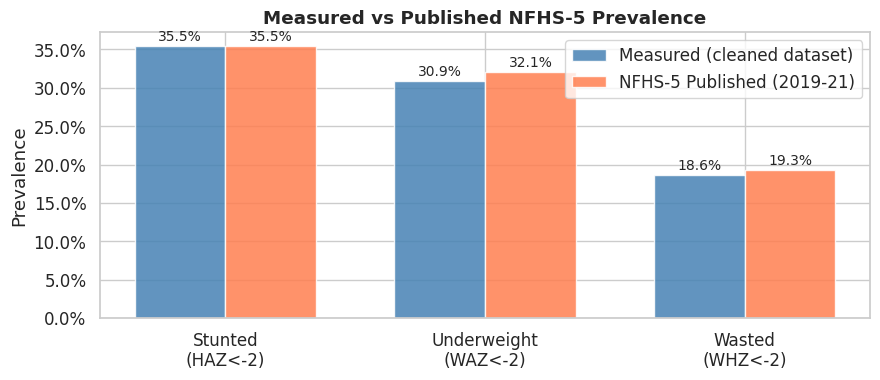

Saved: /workspaces/malnutrisense/reports/figures/prevalence_comparison.png


In [12]:
# Prevalence bar chart — compare measured vs NFHS-5 published figures.
nfhs5_published = {'stunted': 0.355, 'underweight': 0.321, 'wasted': 0.193}
 
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(3)
w = 0.35
bars_measured   = ax.bar(x - w/2, [prevalence[c] for c in TARGET_COLS],
                          w, label='Measured (cleaned dataset)',
                          color='steelblue', alpha=0.85)
bars_published  = ax.bar(x + w/2, [nfhs5_published[c] for c in TARGET_COLS],
                          w, label='NFHS-5 Published (2019-21)',
                          color='coral', alpha=0.85)
 
ax.set_xticks(x)
ax.set_xticklabels(['Stunted\n(HAZ<-2)', 'Underweight\n(WAZ<-2)', 'Wasted\n(WHZ<-2)'])
ax.yaxis.set_major_formatter(ticker.PercentFormatter(1.0))
ax.set_ylabel('Prevalence')
ax.set_title('Measured vs Published NFHS-5 Prevalence', fontweight='bold')
ax.legend()
 
for bar in bars_measured:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=10)
for bar in bars_published:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=10)
 
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'prevalence_comparison.png')
plt.show()
print(f'Saved: {FIGURES_DIR}/prevalence_comparison.png')
 


In [13]:
# Class imbalance — compute scale_pos_weight for XGBoost (save for modelling).
class_weights: dict[str, float] = {}
print('XGBoost scale_pos_weight per label:')
for col in TARGET_COLS:
    valid = df[col].dropna().astype(int)
    pos   = int(valid.sum())
    neg   = int((valid == 0).sum())
    weight = round(neg / pos, 4)
    class_weights[col] = weight
    print(f'  {col:<15} pos={pos:,}  neg={neg:,}  scale_pos_weight={weight}')
 
# Save to tables/ for later use in modelling notebooks
import json
weights_path = TABLES_DIR / 'class_weights.json'
with open(weights_path, 'w') as f:
    json.dump(class_weights, f, indent=2)
print(f'Saved: {weights_path}')
 


XGBoost scale_pos_weight per label:
  stunted         pos=73,070  neg=132,948  scale_pos_weight=1.8195
  underweight     pos=65,040  neg=145,475  scale_pos_weight=2.2367
  wasted          pos=37,553  neg=164,127  scale_pos_weight=4.3705
Saved: /workspaces/malnutrisense/reports/tables/class_weights.json


SECTION 5 — SC/ST VARIABLE ANALYSIS

In [14]:
# Section 5 — SC/ST Variable Analysis
# Detect which column holds SC/ST status in this version of the NFHS file.
# This column is the primary fairness audit grouping variable (Objective 4).
 
from src.preprocessing import detect_sc_st_column
 
sc_st_col = detect_sc_st_column(df)
 
if sc_st_col:
    print(f'SC/ST column detected: {sc_st_col}')
    print(f'Unique coded values:   {sorted(df[sc_st_col].dropna().unique().tolist())}')
    print(f'Missing values:        {df[sc_st_col].isnull().sum():,} ({df[sc_st_col].isnull().mean():.1%})')
else:
    print('WARNING: No SC/ST column found in this dataset.')
    print('Candidates searched: V131, S116, SH46, V130')
    print('Request the Household Members Recode (PR) file .')
    sc_st_col = None
 


2026-05-02 04:46:17  WARNING   src.preprocessing: No SC/ST column found. Searched: ['V131', 'S116', 'SH46', 'V130']. Fairness audit for Scheduled Tribe subgroup will be unavailable. Consider requesting the Household Members Recode (PR) file from DHS.
Candidates searched: V131, S116, SH46, V130
Request the Household Members Recode (PR) file .


In [15]:
# Value counts for the SC/ST column.
# DHS codes: 1=Scheduled Caste, 2=Scheduled Tribe, 3=OBC, 4=None/Other (varies by state).
# The exact mapping varies by file version — check the .DO label file.
if sc_st_col:
    vc = df[sc_st_col].value_counts(dropna=False).rename_axis('code').reset_index()
    vc.columns = ['code', 'count']
    vc['pct'] = (vc['count'] / len(df)).round(4)
    vc['code_label'] = vc['code'].map({
        1.0: 'Scheduled Caste (SC)',
        2.0: 'Scheduled Tribe (ST)',
        3.0: 'OBC',
        4.0: 'None / Other',
        float('nan'): 'NaN (not collected)',
    }).fillna('Other code')
    display(vc[['code','code_label','count','pct']])
else:
    print('SC/ST column not available — skipping value count')
 


SC/ST column not available — skipping value count


In [16]:
# Malnutrition prevalence by SC/ST group.
# Scheduled Tribe children should show higher malnutrition prevalence —
# this is the documented disparity we address in the fairness audit.
if sc_st_col:
    grouped = (
        df.groupby(sc_st_col)[TARGET_COLS]
        .mean()
        .round(3)
        .rename(index={
            1.0: 'SC', 2.0: 'ST', 3.0: 'OBC', 4.0: 'None/Other'
        })
    )
    print('Malnutrition prevalence by SC/ST group:')
    display(grouped.style.format('{:.1%}').background_gradient(cmap='Reds', axis=None))
    grouped.to_csv(TABLES_DIR / 'prevalence_by_scst.csv')
    print(f'Saved: {TABLES_DIR}/prevalence_by_scst.csv')
else:
    print('SC/ST column not available — skipping group analysis')
 


SC/ST column not available — skipping group analysis


In [17]:
# Visualise SC/ST group prevalence differences.
if sc_st_col and grouped is not None:
    fig, ax = plt.subplots(figsize=(10, 4))
    grouped.plot(kind='bar', ax=ax, color=['#2196F3','#FF5722','#4CAF50'],
                 alpha=0.85, edgecolor='white', width=0.7)
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(1.0))
    ax.set_ylabel('Prevalence')
    ax.set_xlabel('Caste / Tribe Group')
    ax.set_title('Malnutrition Prevalence by SC/ST Group', fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title='Phenotype', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'prevalence_by_scst.png')
    plt.show()
    print(f'Saved: {FIGURES_DIR}/prevalence_by_scst.png')
else:
    print('SC/ST column not available — no chart produced')
 


SC/ST column not available — no chart produced


SECTION 6 — SUMMARY CELL

In [18]:
# Section 6 — Notebook Summary
# This cell always runs last. It confirms what was produced and logged.
 
figures_produced = list(FIGURES_DIR.glob('*.png'))
tables_produced  = list(TABLES_DIR.glob('*.csv')) + list(TABLES_DIR.glob('*.json'))
 
print('='*55)
print('01_data_loading.ipynb — Complete')
print('='*55)
print(f'Dataset:  {format_number(len(df))} rows x {df.shape[1]} columns')
print(f'Stunted:  {prevalence["stunted"]:.1%}')
print(f'Underweight: {prevalence["underweight"]:.1%}')
print(f'Wasted:   {prevalence["wasted"]:.1%}')
print(f'SC/ST col:   {sc_st_col or "NOT FOUND"}')
print(f'Figures:  {len(figures_produced)} saved to {FIGURES_DIR}')
for f in sorted(figures_produced):
    print(f'  {f.name}')
print(f'Tables:   {len(tables_produced)} saved to {TABLES_DIR}')
for t in sorted(tables_produced):
    print(f'  {t.name}')
print('='*55)



01_data_loading.ipynb — Complete
Dataset:  228,356 rows x 17 columns
Stunted:  35.5%
Underweight: 30.9%
Wasted:   18.6%
SC/ST col:   NOT FOUND
Figures:  4 saved to /workspaces/malnutrisense/reports/figures
  missing_values_heatmap.png
  prevalence_comparison.png
  zscore_correlation.png
  zscore_distributions.png
Tables:   3 saved to /workspaces/malnutrisense/reports/tables
  class_weights.json
  pipeline_summary.csv
  validation_summary.csv
